In [70]:
! pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed. RF will be used.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed. Feature importance will be used instead.")

# 1. Load and Explore Dataset

In [72]:
df = pd.read_csv("/kaggle/input/datasets/yashxss/nasa-battery-cycle-level-dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv")
print(df.head(10))
print(f"\nShape: {df.shape}\n")
print(f"Columns: {df.columns.tolist()}")
print(f"Number of unique batteries: {df['battery_id'].nunique()}")
print("\nBattery cycle counts (top 10):")
print(df['battery_id'].value_counts().head(10))
print("\n Statistics: \n")
print(df.describe().round(3))

print(f"\nSOH > 1.0 count: {(df['soh'] > 1.0).sum()} (normal when SOH is relative to first cycle of each battery)")

  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163
5      B0005      6  3.555518    32.251242  1.841138  0.988808  162
6      B0005      7  3.550392    32.366192  1.840621  0.988531  161
7      B0005      8  3.557436    32.367489  1.831164  0.983452  160
8      B0005      9  3.553497    32.339648  1.839546  0.987953  159
9      B0005     10  3.557888    32.191180  1.830019  0.982837  158

Shape: (1415, 7)

Columns: ['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul']
Number of unique batteries: 34

Battery cycle counts (top 10):
battery_id
B0005    168
B0007    168
B0006    155
B0018    132
B0042     99
B0045    

# 2. Data Preprocessing

In [73]:
feature_cols_base = ["voltage", "temperature", "capacity"]
feature_cols_with_cycle = ["voltage", "temperature", "capacity", "cycle"]

target = "soh"
group_col = "battery_id"

# Simple cleaning
df = df.dropna(subset=feature_cols_with_cycle + [target])
print(f"Rows after dropna: {len(df)}")

Rows after dropna: 1415


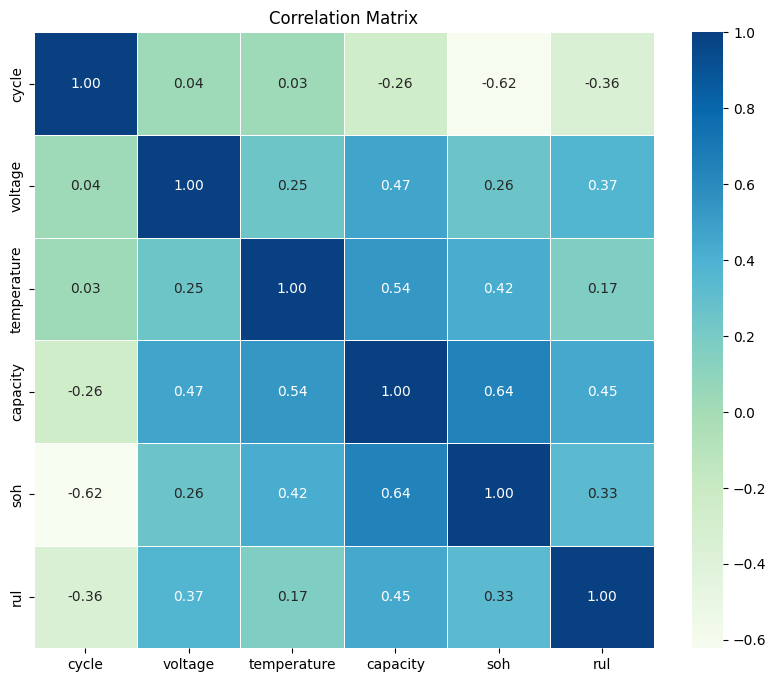

In [74]:
plt.figure(figsize=(10, 8))
cols = ["cycle", "voltage", "temperature", "capacity", "soh", "rul"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", linewidths=0.5, cmap="GnBu")
plt.title("Correlation Matrix")
plt.show()

# 3. Training / Validation / Testing Strategy


In [75]:
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# 4. Model Training and Evaluation Function


In [76]:
def evaluate_model(model, X, y, groups, feature_names, model_name="Model"):
    """Cross-validate with GroupKFold and return metrics + predictions."""
    mae_list, rmse_list, r2_list, mape_list = [], [], [], []
    all_y_true, all_y_pred, all_batteries = [], [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Optional scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

        mae_list.append(mae)
        rmse_list.append(rmse)
        r2_list.append(r2)
        mape_list.append(mape)

        all_y_true.extend(y_test.values)
        all_y_pred.extend(y_pred)
        all_batteries.extend(groups.iloc[test_idx].values)

        print(f"  Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}, MAPE={mape:.2f}%")

    results = {
        "model_name": model_name,
        "MAE_mean": np.mean(mae_list),
        "MAE_std": np.std(mae_list),
        "RMSE_mean": np.mean(rmse_list),
        "RMSE_std": np.std(rmse_list),
        "R2_mean": np.mean(r2_list),
        "R2_std": np.std(r2_list),
        "MAPE_mean": np.mean(mape_list),
        "MAPE_std": np.std(mape_list),
        "y_true": np.array(all_y_true),
        "y_pred": np.array(all_y_pred),
        "batteries": all_batteries
    }
    return results

# 5. Experiments


In [77]:
y = df[target]
groups = df[group_col]

# Experiment A: Without cycle number (less leakage risk)
print("\n--- Experiment A: Features = [voltage, temperature, capacity] ---")
X_a = df[feature_cols_base]
rf_a = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
results_a = evaluate_model(rf_a, X_a, y, groups, feature_cols_base, "RF (no cycle)")

# Experiment B: With cycle number (to demonstrate leakage)
print("\n--- Experiment B: Features = [voltage, temperature, capacity, cycle] ---")
X_b = df[feature_cols_with_cycle]
rf_b = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
results_b = evaluate_model(rf_b, X_b, y, groups, feature_cols_with_cycle, "RF (with cycle)")

# Optional XGBoost
if HAS_XGB:
    print("\n--- Experiment C: XGBoost without cycle ---")
    xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
    results_xgb = evaluate_model(xgb, X_a, y, groups, feature_cols_base, "XGBoost (no cycle)")


--- Experiment A: Features = [voltage, temperature, capacity] ---
  Fold 1: MAE=0.0252, RMSE=0.0318, R2=0.8854, MAPE=2.91%
  Fold 2: MAE=0.0361, RMSE=0.0539, R2=0.7235, MAPE=4.08%
  Fold 3: MAE=0.0723, RMSE=0.0903, R2=0.5458, MAPE=9.71%
  Fold 4: MAE=0.0710, RMSE=0.0849, R2=0.3906, MAPE=8.61%
  Fold 5: MAE=0.0984, RMSE=0.1460, R2=-0.1003, MAPE=13.69%

--- Experiment B: Features = [voltage, temperature, capacity, cycle] ---
  Fold 1: MAE=0.0167, RMSE=0.0250, R2=0.9290, MAPE=1.90%
  Fold 2: MAE=0.0246, RMSE=0.0415, R2=0.8365, MAPE=2.75%
  Fold 3: MAE=0.0564, RMSE=0.0677, R2=0.7449, MAPE=7.58%
  Fold 4: MAE=0.0829, RMSE=0.1403, R2=-0.6654, MAPE=8.87%
  Fold 5: MAE=0.0762, RMSE=0.1281, R2=0.1522, MAPE=11.12%

--- Experiment C: XGBoost without cycle ---
  Fold 1: MAE=0.0274, RMSE=0.0360, R2=0.8528, MAPE=3.11%
  Fold 2: MAE=0.0395, RMSE=0.0578, R2=0.6826, MAPE=4.52%
  Fold 3: MAE=0.0764, RMSE=0.0968, R2=0.4781, MAPE=10.27%
  Fold 4: MAE=0.0835, RMSE=0.1036, R2=0.0928, MAPE=10.10%
  Fold 5: 

# 6. Summary of Results


In [78]:
def print_summary(res):
    print(f"\n{res['model_name']}:")
    print(f"  MAE  : {res['MAE_mean']:.4f} ± {res['MAE_std']:.4f}")
    print(f"  RMSE : {res['RMSE_mean']:.4f} ± {res['RMSE_std']:.4f}")
    print(f"  R²   : {res['R2_mean']:.4f} ± {res['R2_std']:.4f}")
    print(f"  MAPE : {res['MAPE_mean']:.2f}% ± {res['MAPE_std']:.2f}%")

print_summary(results_a)
print_summary(results_b)
if HAS_XGB:
    print_summary(results_xgb)


RF (no cycle):
  MAE  : 0.0606 ± 0.0265
  RMSE : 0.0814 ± 0.0387
  R²   : 0.4890 ± 0.3383
  MAPE : 7.80% ± 3.92%

RF (with cycle):
  MAE  : 0.0514 ± 0.0267
  RMSE : 0.0805 ± 0.0461
  R²   : 0.3995 ± 0.5976
  MAPE : 6.44% ± 3.56%

XGBoost (no cycle):
  MAE  : 0.0625 ± 0.0242
  RMSE : 0.0863 ± 0.0356
  R²   : 0.4266 ± 0.3229
  MAPE : 7.96% ± 3.46%


# 7. Feature Importance & Explainability


In [79]:
# Retrain on full data for final importance (for illustration)
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(df[feature_cols_base])
rf_final = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_final.fit(X_final, y)

importances = pd.Series(rf_final.feature_importances_, index=feature_cols_base).sort_values(ascending=False)
print(importances)

capacity       0.631513
voltage        0.249008
temperature    0.119479
dtype: float64


# 8. Visualization


Saved: soh_results_overview.png


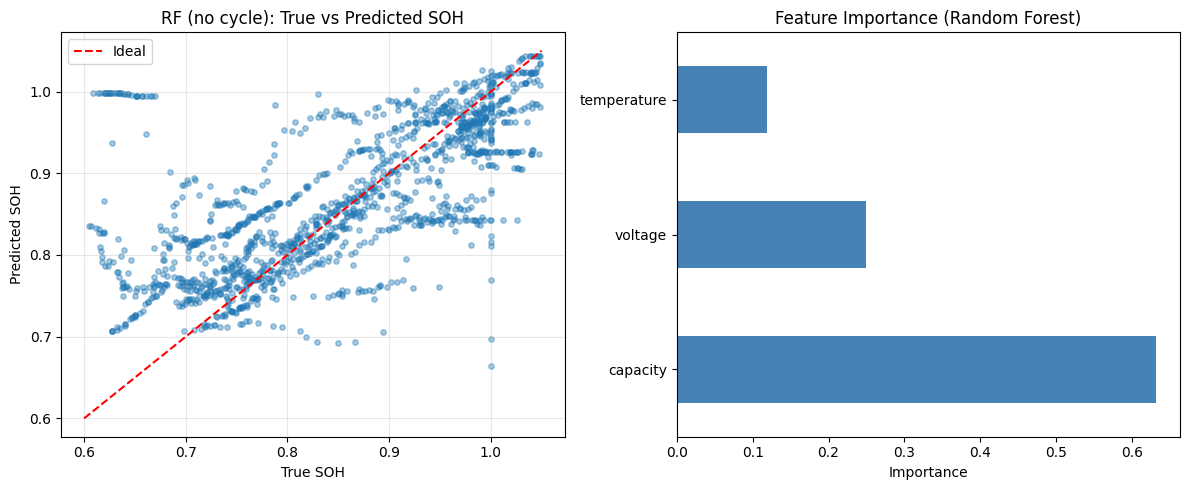

In [80]:
plt.figure(figsize=(12, 5))

# Plot 1: True vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(results_a["y_true"], results_a["y_pred"], alpha=0.4, s=15)
plt.plot([0.6, 1.05], [0.6, 1.05], "r--", label="Ideal")
plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("RF (no cycle): True vs Predicted SOH")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Feature Importance
plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.savefig("soh_results_overview.png", dpi=150, bbox_inches="tight")
print("Saved: soh_results_overview.png")

#  SHAP

Computing SHAP values
Saved: shap_summary.png


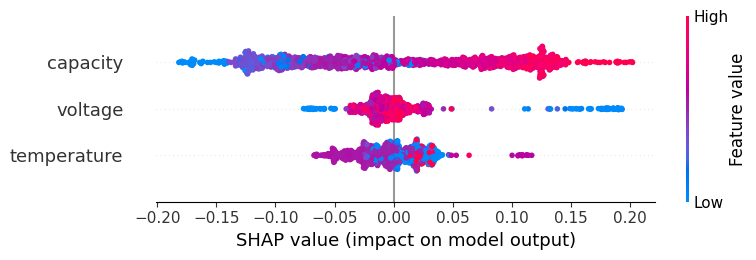

In [83]:
if HAS_SHAP:
    print("Computing SHAP values")
    explainer = shap.TreeExplainer(rf_final)
    shap_values = explainer.shap_values(X_final)
    plt.figure()
    shap.summary_plot(shap_values, X_final, feature_names=feature_cols_base, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
    print("Saved: shap_summary.png")